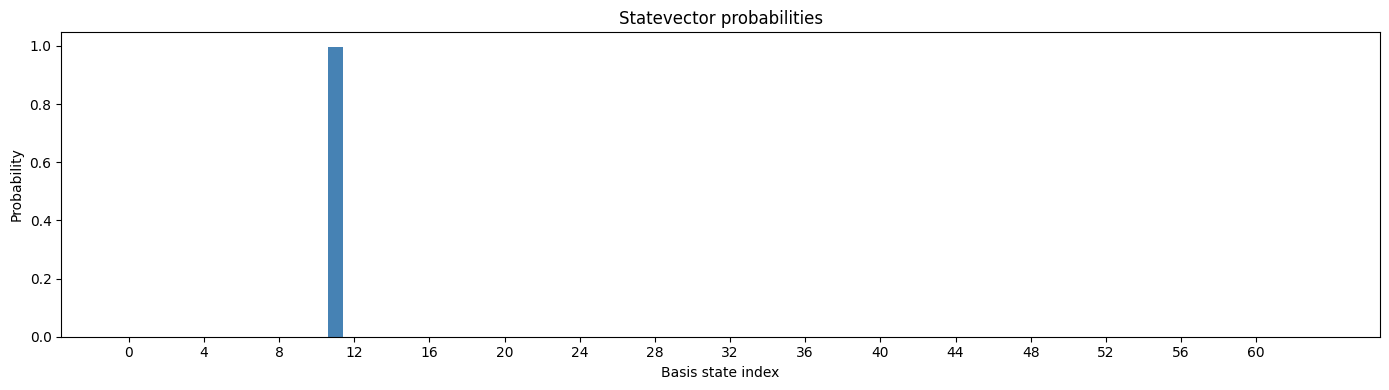

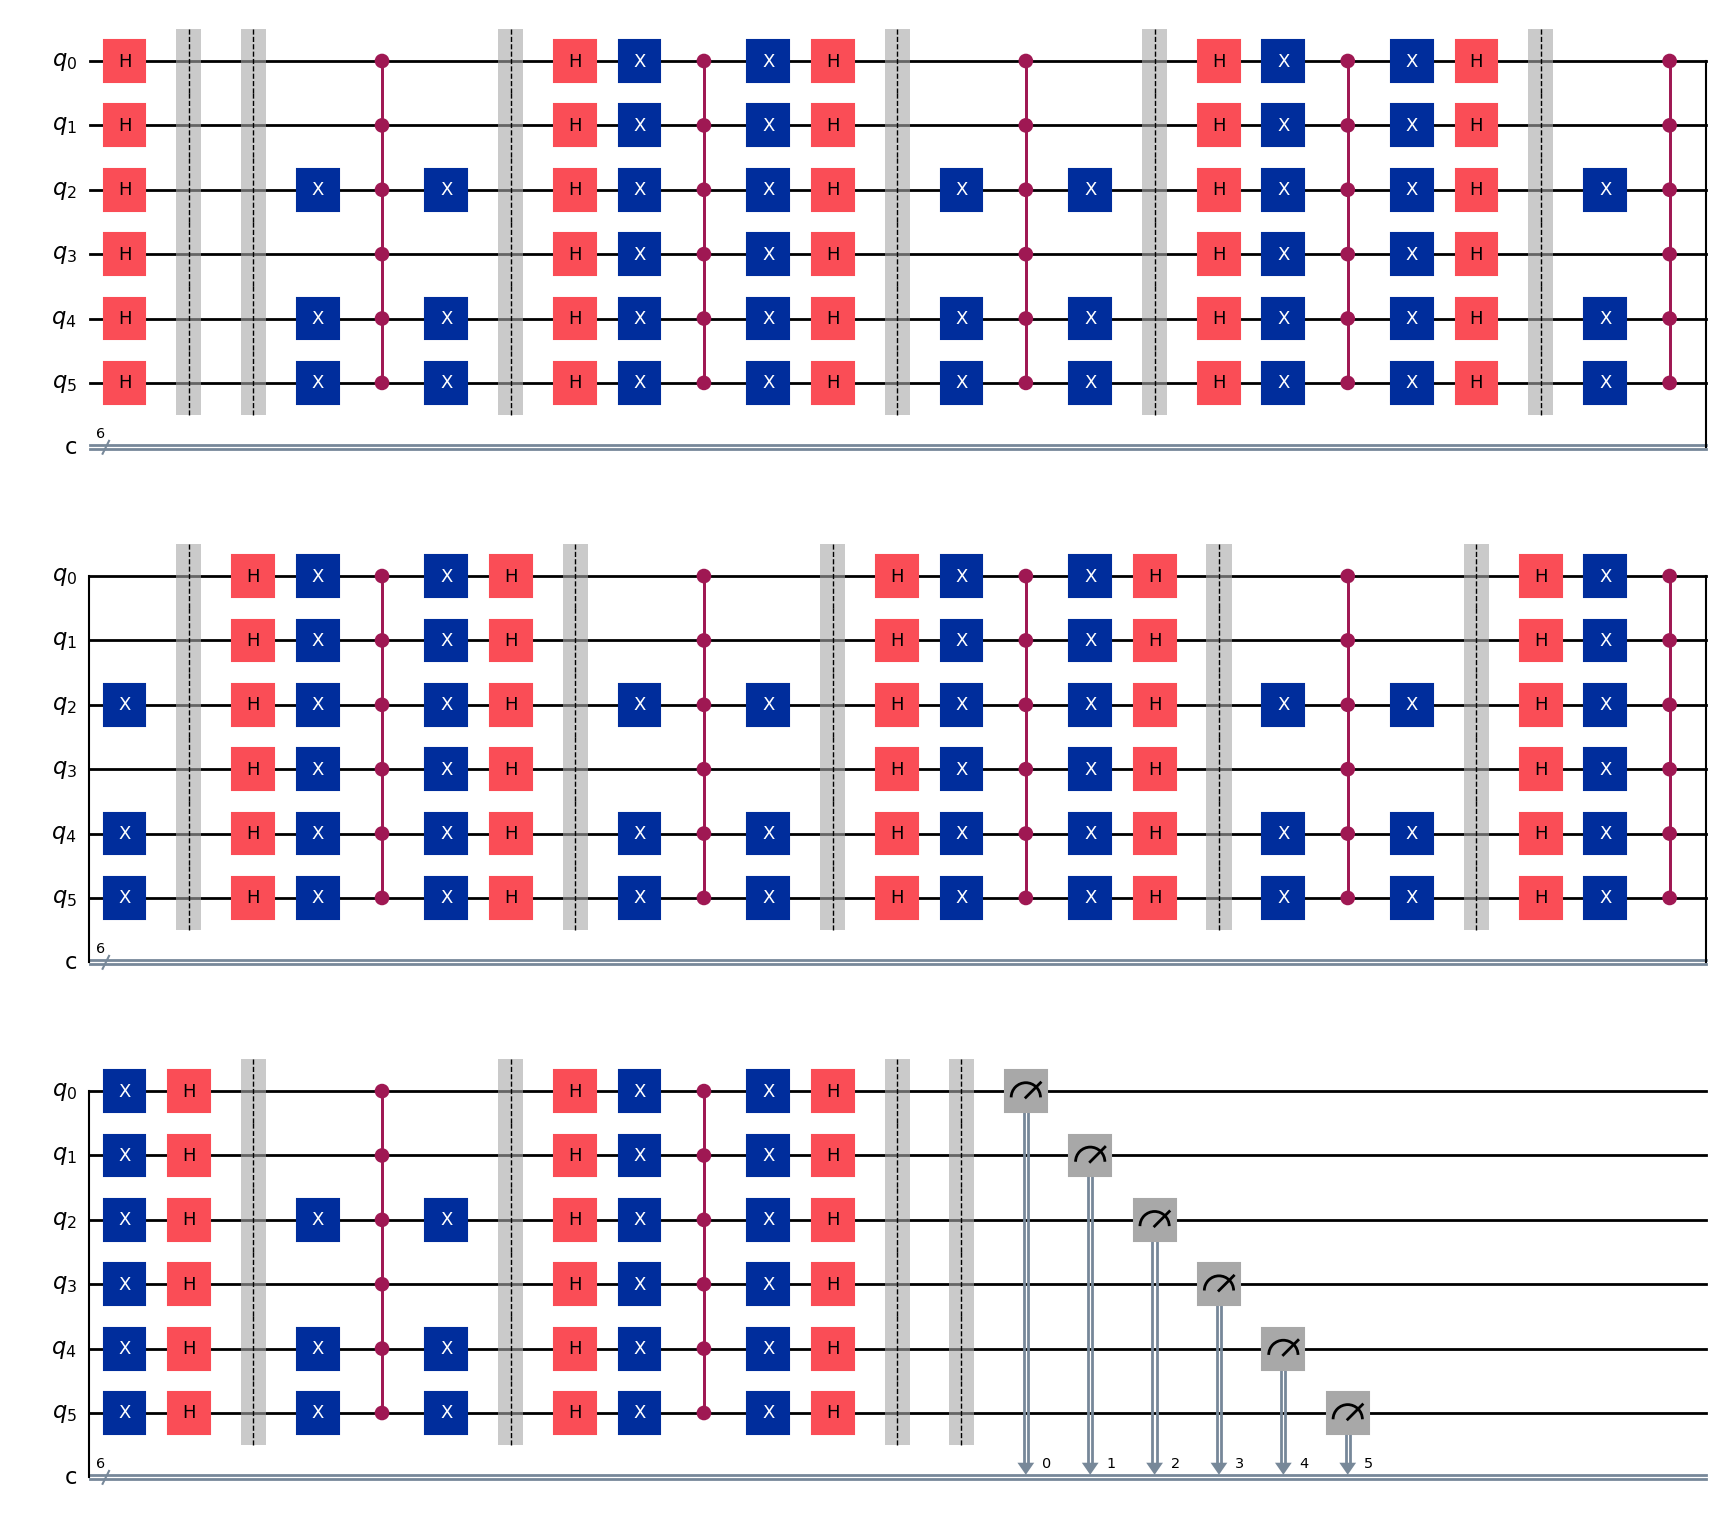

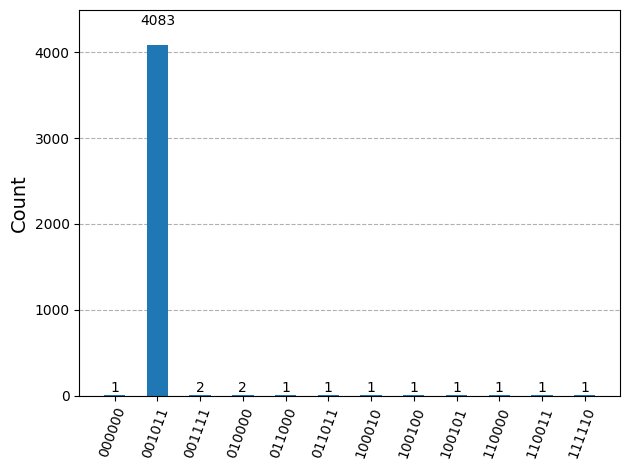

In [2]:
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.circuit.library import ZGate
import math
import numpy as np
import matplotlib.pyplot as plt

def present_run(qc):
    
    #statevector probabilities
    qc_sv = qc.copy()
    qc_sv.remove_final_measurements(inplace=True)
    sv = Statevector(qc_sv)
    probs = np.abs(sv.data) ** 2

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(len(probs)), probs, color='steelblue', width=0.8)
    ax.set_xlabel('Basis state index')
    ax.set_ylabel('Probability')
    ax.set_title('Statevector probabilities')
    ax.set_xticks(range(0, len(probs), 4))
    plt.tight_layout()
    display(fig)
    plt.close(fig)
   

    # experimental counts
    from qiskit import transpile
    simulator = AerSimulator()
    compiled = transpile(qc, simulator)
    job = simulator.run(compiled, shots=2**12)
    counts = job.result().get_counts()
    display(qc.draw('mpl'))
    display(plot_histogram(counts))




def initialization(qc, n_qubits):
    # Apply Hadamard to all qubits
    for i in range(n_qubits):
        qc.h(i)

def oracle_single(solution_index, qc, n_qubits):
    #Important to note that for qiskit: the upper most qubit (le least significant)
    # is placed at the extreme right in brac ket notation ex: |q1 q0> where q0 is top and q1 is bottom
    # index 1 = |00>, index 2 = |01>, index 3 = |10>, index 4 = |11>
    # 6 qubits can have up to 64 = 2^6 possible states
    # We will denote this as going from position 0 to position 63
    
    # Also, note that there is only one solution here, not multiple
    
    # Convert index to binary string, then flips it to that the top qubit is on the left
    bits = format(solution_index, f'0{n_qubits}b')[::-1]  

    # Step 1: X on every qubit whose bit is '0'
    zero_qubits = [i for i, b in enumerate(bits) if b == '0'] #Index of 0 qubits
    if zero_qubits:
        qc.x(zero_qubits) #applies X to all qubits in zero_qubits list

    # Step 2: multi-controlled Z (CZ) 
    # Fires only on |111111⟩
    # clean multi-controlled Z — no H trick needed
    qc.append(ZGate().control(n_qubits - 1), list(range(n_qubits)))

    #Reapply X to original "0"
    if zero_qubits:
        qc.x(zero_qubits)

def oracle_multi( solution_indices, qc, n_qubits):
    
    #Applies oracle_single once per solution — this stacks
    
    for index in solution_indices:
        oracle_single(index, qc, n_qubits)    

def diffusion_operator(qc, n_qubits,):
    # Apply Hadamard to all qubits

   
    for i in range(n_qubits):
        qc.h(i)
    for i in range(n_qubits):
        qc.x(i)

    qc.append(ZGate().control(n_qubits - 1), list(range(n_qubits)))

    for i in range(n_qubits):
        qc.x(i)
    for i in range(n_qubits):
        qc.h(i)
    

    
    





#creating circuit object with 6 qubits and 6 classical measurement bits
n_qubits = 6
solutions_M = [11]
qc = QuantumCircuit(n_qubits, n_qubits)
iterations = round(math.pi*math.sqrt(2**n_qubits/len(solutions_M))/4) #tries to optimize the number of iterations based on the number of solutions and total states
#initialization
initialization(qc, n_qubits)
qc.barrier()
qc.barrier()
#oracle
for j in range(iterations):

    oracle_multi(solutions_M, qc, n_qubits) #multiple solutions
    qc.barrier()
    #diffusion 
    diffusion_operator(qc, n_qubits)
    qc.barrier()
    #measurement 


qc.barrier()
qc.measure(list(range(n_qubits)), list(range(n_qubits))) #qubit to its coresponding classical bit

#Present results
present_run(qc)